# Phase 2 — Feature Engineering & Shock Labeling
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Goals:**
1. Load master dataset from Phase 1
2. Label shock periods (2008 Great Recession, 2020 COVID-19)
3. Engineer recovery features: recovery speed & recovery quality
4. Create lag features and rolling statistics
5. Create GDP growth rate features
6. Save enriched dataset for modeling phases

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Master Dataset

In [2]:
master = pd.read_csv(r'..\output\master_dataset.csv')
master = master.sort_values(['country_code', 'year']).reset_index(drop=True)

print('Shape:', master.shape)
print('Years:', master['year'].min(), '-', master['year'].max())
print('Countries:', master['country_code'].nunique())
print('Columns:', master.columns.tolist())
master.head(5)

Shape: (7240, 8)
Years: 1990 - 2024
Countries: 212
Columns: ['country_code', 'year', 'gdp_per_capita', 'population', 'inflation_hcpi', 'dependency_ratio', 'employment_rate', 'interest_rate']


,country_code,year,gdp_per_capita,population,inflation_hcpi,dependency_ratio,employment_rate,interest_rate
0,ABW,1990,33063.0000,62753.0000,2.8900,48.3885,NaN,4.5666
1,ABW,1991,33993.2070,65896.0000,2.8900,50.2383,NaN,4.7911
2,ABW,1992,34371.1640,69005.0000,2.8900,51.0353,NaN,6.5281
3,ABW,1993,34540.3360,73685.0000,2.8900,50.4216,NaN,5.0329
4,ABW,1994,35490.7230,77595.0000,2.8900,49.7915,NaN,4.0569


## 3. Define Shock Periods

Two major global economic shocks are labeled based on established references:

| Shock | Period | Basis |
|---|---|---|
| 2008 Great Recession | 2008–2009 | Global GDP contraction, financial crisis |
| 2020 COVID-19 | 2020–2021 | Global pandemic, supply & demand shock |

In [3]:
# Define shock windows
SHOCK_PERIODS = {
    'recession_2008': (2008, 2009),
    'covid_2020':     (2020, 2021),
}

# Binary shock flag: 1 if year falls within any shock period
def is_shock_year(year):
    for name, (start, end) in SHOCK_PERIODS.items():
        if start <= year <= end:
            return 1
    return 0

master['is_shock'] = master['year'].apply(is_shock_year)

# Named shock label for reference
def shock_name(year):
    if 2008 <= year <= 2009:
        return 'recession_2008'
    elif 2020 <= year <= 2021:
        return 'covid_2020'
    return 'none'

master['shock_label'] = master['year'].apply(shock_name)

print('Shock year distribution:')
print(master['shock_label'].value_counts())
print()
print('is_shock flag counts:', master['is_shock'].value_counts().to_dict())

Shock year distribution:
shock_label
none              6395
covid_2020         424
recession_2008     421
Name: count, dtype: int64

is_shock flag counts: {0: 6395, 1: 845}


## 4. GDP Growth Rate

Year-over-year percentage change in GDP per capita — core indicator for detecting shocks and measuring recovery.

In [4]:
# GDP YoY growth rate (%) — computed within each country
master['gdp_growth_rate'] = master.groupby('country_code')['gdp_per_capita'].transform(
    lambda x: x.pct_change() * 100
)

print('GDP growth rate stats:')
print(master['gdp_growth_rate'].describe())
print('Missing:', master['gdp_growth_rate'].isna().sum())

GDP growth rate stats:
count   7028.0000
mean       1.9214
std        6.4046
min      -64.4236
25%       -0.1387
50%        2.1079
75%        4.2937
max      140.4906
Name: gdp_growth_rate, dtype: float64
Missing: 212


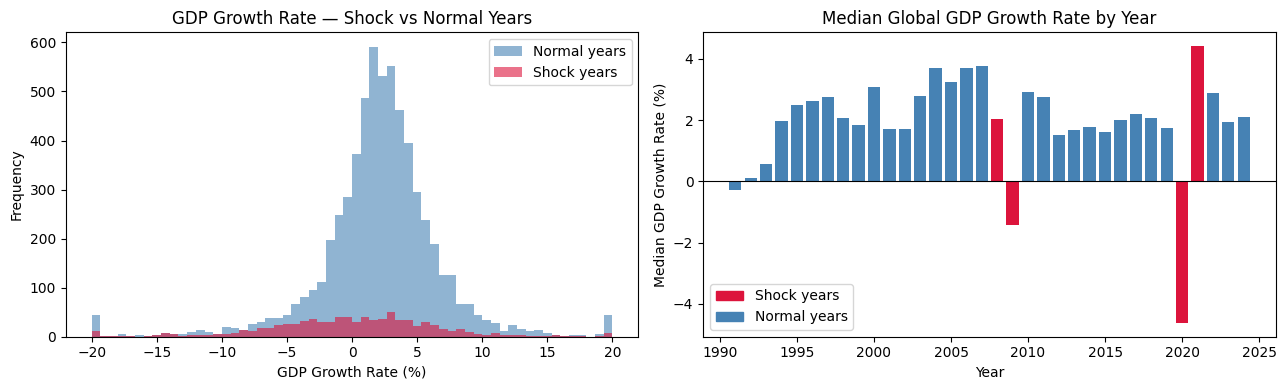

In [5]:
# Visualize GDP growth distribution during shocks vs normal years
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution comparison
shock_data  = master[master['is_shock'] == 1]['gdp_growth_rate'].dropna()
normal_data = master[master['is_shock'] == 0]['gdp_growth_rate'].dropna()

axes[0].hist(normal_data.clip(-20, 20), bins=60, alpha=0.6, color='steelblue', label='Normal years')
axes[0].hist(shock_data.clip(-20, 20),  bins=60, alpha=0.6, color='crimson',   label='Shock years')
axes[0].set_title('GDP Growth Rate — Shock vs Normal Years')
axes[0].set_xlabel('GDP Growth Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Global average GDP growth by year
avg_growth = master.groupby('year')['gdp_growth_rate'].median()
colors = ['crimson' if is_shock_year(y) else 'steelblue' for y in avg_growth.index]
axes[1].bar(avg_growth.index, avg_growth.values, color=colors, edgecolor='none')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Median Global GDP Growth Rate by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Median GDP Growth Rate (%)')
red_patch   = mpatches.Patch(color='crimson',   label='Shock years')
blue_patch  = mpatches.Patch(color='steelblue', label='Normal years')
axes[1].legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.savefig(r'..\output\gdp_growth_shock_vs_normal.png', dpi=150)
plt.show()

## 5. Recovery Speed Feature

**Definition:** Number of years it takes for a country's GDP per capita to return to its pre-shock level after each shock.

- Pre-shock level = GDP value in the year **before** the shock starts
- Recovery year = first year after the shock where GDP >= pre-shock level
- Recovery speed = recovery year − shock start year

In [6]:
def compute_recovery_speed(df, shock_start, shock_name_label):
    """
    For each country, compute how many years after shock_start
    it takes GDP to recover to pre-shock level.
    Returns a DataFrame with country_code and recovery_speed.
    """
    records = []
    pre_shock_year = shock_start - 1

    for country, group in df.groupby('country_code'):
        group = group.sort_values('year')

        pre_gdp_row = group[group['year'] == pre_shock_year]
        if pre_gdp_row.empty:
            continue
        pre_gdp = pre_gdp_row['gdp_per_capita'].values[0]
        if pd.isna(pre_gdp):
            continue

        # Post-shock years
        post_shock = group[group['year'] > shock_start].copy()
        recovered = post_shock[post_shock['gdp_per_capita'] >= pre_gdp]

        if not recovered.empty:
            recovery_year = recovered['year'].min()
            speed = recovery_year - shock_start
        else:
            speed = np.nan  # Not yet recovered within dataset range

        records.append({
            'country_code': country,
            'shock': shock_name_label,
            'pre_shock_gdp': pre_gdp,
            'recovery_speed_years': speed,
        })

    return pd.DataFrame(records)


speed_2008 = compute_recovery_speed(master, shock_start=2008, shock_name_label='recession_2008')
speed_2020 = compute_recovery_speed(master, shock_start=2020, shock_name_label='covid_2020')

recovery_speed_df = pd.concat([speed_2008, speed_2020], ignore_index=True)

print('Recovery speed computed:')
print(recovery_speed_df.groupby('shock')['recovery_speed_years'].describe())

Recovery speed computed:
                  count   mean    std    min    25%    50%    75%     max
shock                                                                    
covid_2020     171.0000 1.5965 0.8372 1.0000 1.0000 1.0000 2.0000  4.0000
recession_2008 191.0000 2.6911 3.0024 1.0000 1.0000 1.0000 3.0000 16.0000


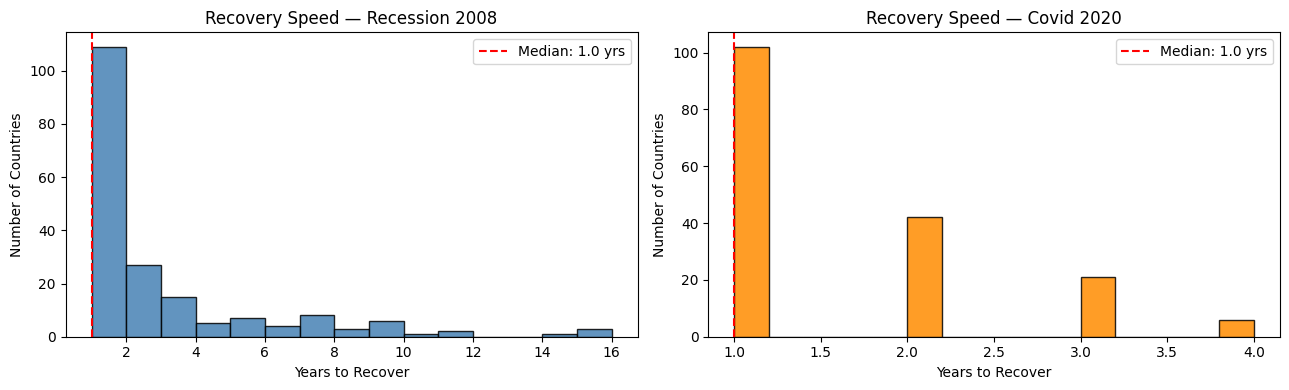


2008 Recession — countries not yet recovered: 17
COVID-19 2020  — countries not yet recovered: 41


In [7]:
# Visualize recovery speed distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (shock_lbl, color) in zip(axes, [('recession_2008', 'steelblue'), ('covid_2020', 'darkorange')]):
    data = recovery_speed_df[recovery_speed_df['shock'] == shock_lbl]['recovery_speed_years'].dropna()
    ax.hist(data, bins=15, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.1f} yrs')
    ax.set_title(f'Recovery Speed — {shock_lbl.replace("_", " ").title()}')
    ax.set_xlabel('Years to Recover')
    ax.set_ylabel('Number of Countries')
    ax.legend()

plt.tight_layout()
plt.savefig(r'..\output\recovery_speed_distribution.png', dpi=150)
plt.show()

print(f"\n2008 Recession — countries not yet recovered: {speed_2008['recovery_speed_years'].isna().sum()}")
print(f"COVID-19 2020  — countries not yet recovered: {speed_2020['recovery_speed_years'].isna().sum()}")

## 6. Recovery Quality Feature

**Definition:** The percentage of pre-shock GDP level that a country has regained after a fixed window (3 years post-shock).

$$\text{Recovery Quality} = \frac{\text{GDP}_{t+3}}{\text{GDP}_{\text{pre-shock}}} \times 100$$

- > 100% = fully recovered and exceeded pre-shock level
- 80–100% = partial recovery
- < 80% = poor recovery

In [8]:
def compute_recovery_quality(df, shock_start, shock_name_label, window=3):
    """
    Recovery quality = GDP at (shock_start + window) / pre-shock GDP * 100.
    """
    records = []
    pre_shock_year  = shock_start - 1
    measure_year    = shock_start + window

    for country, group in df.groupby('country_code'):
        group = group.sort_values('year')

        pre_row     = group[group['year'] == pre_shock_year]
        measure_row = group[group['year'] == measure_year]

        if pre_row.empty or measure_row.empty:
            continue

        pre_gdp     = pre_row['gdp_per_capita'].values[0]
        measure_gdp = measure_row['gdp_per_capita'].values[0]

        if pd.isna(pre_gdp) or pd.isna(measure_gdp) or pre_gdp == 0:
            continue

        quality = (measure_gdp / pre_gdp) * 100

        records.append({
            'country_code':          country,
            'shock':                 shock_name_label,
            'pre_shock_gdp':         pre_gdp,
            'post_shock_gdp':        measure_gdp,
            'recovery_quality_pct':  quality,
        })

    return pd.DataFrame(records)


quality_2008 = compute_recovery_quality(master, shock_start=2008, shock_name_label='recession_2008', window=3)
quality_2020 = compute_recovery_quality(master, shock_start=2020, shock_name_label='covid_2020',     window=3)

recovery_quality_df = pd.concat([quality_2008, quality_2020], ignore_index=True)

print('Recovery quality computed:')
print(recovery_quality_df.groupby('shock')['recovery_quality_pct'].describe())

Recovery quality computed:
                  count     mean     std     min     25%      50%      75%  \
shock                                                                        
covid_2020     210.0000 104.4452 20.5390 60.1590 99.2173 103.7592 108.0171   
recession_2008 208.0000 106.6284 12.9956 47.9079 99.1623 105.9264 114.7100   

                    max  
shock                    
covid_2020     367.9362  
recession_2008 151.0360  


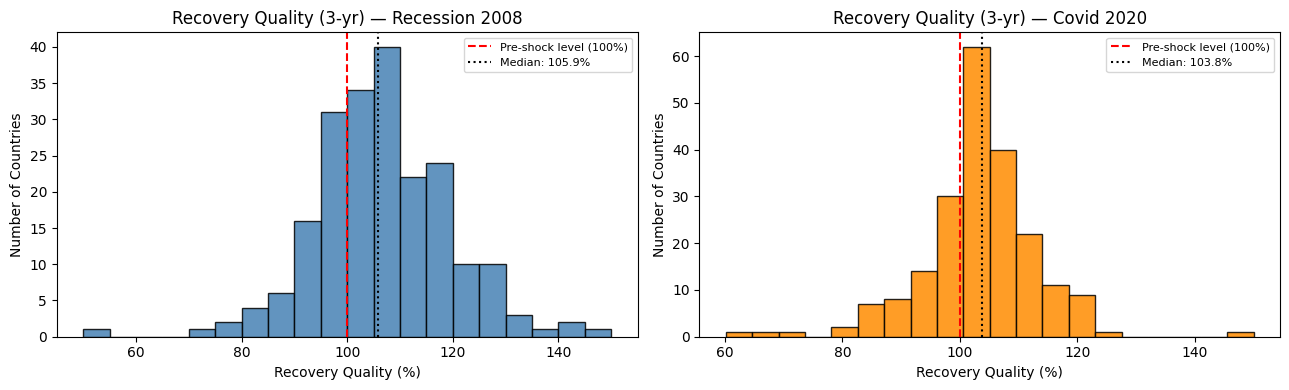

In [9]:
# Visualize recovery quality
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (shock_lbl, color) in zip(axes, [('recession_2008', 'steelblue'), ('covid_2020', 'darkorange')]):
    data = recovery_quality_df[recovery_quality_df['shock'] == shock_lbl]['recovery_quality_pct'].dropna()
    ax.hist(data.clip(50, 150), bins=20, color=color, edgecolor='black', alpha=0.85)
    ax.axvline(100, color='red',   linestyle='--', linewidth=1.5, label='Pre-shock level (100%)')
    ax.axvline(data.median(), color='black', linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}%')
    ax.set_title(f'Recovery Quality (3-yr) — {shock_lbl.replace("_", " ").title()}')
    ax.set_xlabel('Recovery Quality (%)')
    ax.set_ylabel('Number of Countries')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'..\output\recovery_quality_distribution.png', dpi=150)
plt.show()

## 7. Merge Recovery Features Back to Master

In [10]:
# Combine speed + quality into one recovery summary
recovery_summary = recovery_speed_df.merge(
    recovery_quality_df[['country_code', 'shock', 'recovery_quality_pct']],
    on=['country_code', 'shock'],
    how='left'
)

print('Recovery summary shape:', recovery_summary.shape)
recovery_summary.head()

Recovery summary shape: (420, 5)


,country_code,shock,pre_shock_gdp,recovery_speed_years,recovery_quality_pct
0,ABW,recession_2008,39462.5860,11.0000,88.2809
1,AFG,recession_2008,2155.3530,1.0000,127.9165
2,AGO,recession_2008,10437.5900,1.0000,105.7489
3,ALB,recession_2008,10262.9670,1.0000,118.4172
4,AND,recession_2008,65534.1170,16.0000,92.2733


In [11]:
# Pivot: one row per country, separate columns for each shock
speed_pivot = recovery_speed_df.pivot(index='country_code', columns='shock', values='recovery_speed_years')
speed_pivot.columns = [f'recovery_speed_{c}' for c in speed_pivot.columns]

quality_pivot = recovery_quality_df.pivot(index='country_code', columns='shock', values='recovery_quality_pct')
quality_pivot.columns = [f'recovery_quality_{c}' for c in quality_pivot.columns]

recovery_pivot = speed_pivot.join(quality_pivot, how='outer').reset_index()

print('Recovery pivot shape:', recovery_pivot.shape)
print('Columns:', recovery_pivot.columns.tolist())
recovery_pivot.head()

Recovery pivot shape: (212, 5)
Columns: ['country_code', 'recovery_speed_covid_2020', 'recovery_speed_recession_2008', 'recovery_quality_covid_2020', 'recovery_quality_recession_2008']


,country_code,recovery_speed_covid_2020,recovery_speed_recession_2008,recovery_quality_covid_2020,recovery_quality_recession_2008
0,ABW,3.0000,11.0000,105.8310,88.2809
1,AFG,NaN,1.0000,67.7706,127.9165
2,AGO,NaN,1.0000,91.0888,105.7489
3,ALB,1.0000,1.0000,122.1932,118.4172
4,AND,2.0000,16.0000,102.2390,92.2733


In [12]:
# Merge recovery features into master (each country-year row gets its country's recovery info)
master = master.merge(recovery_pivot, on='country_code', how='left')

print('Master shape after recovery merge:', master.shape)
print('New columns:', [c for c in master.columns if 'recovery' in c])

Master shape after recovery merge: (7240, 15)
New columns: ['recovery_speed_covid_2020', 'recovery_speed_recession_2008', 'recovery_quality_covid_2020', 'recovery_quality_recession_2008']


## 8. Lag Features

Lag features provide the model with historical context — how GDP looked 1, 2, and 3 years ago.

In [13]:
master = master.sort_values(["country_code", "year"])

# ── Lag Features ───────────────────────────────────────────────────────────
# Keep lag_1 and lag_2 only.
# lag_3 is redundant — its information is already captured by gdp_rolling_mean_3yr.
# Keep growth_lag_1 only (momentum signal). Higher growth lags add multicollinearity.
for lag in [1, 2]:
    master[f"gdp_lag_{lag}"] = master.groupby("country_code")["gdp_per_capita"].transform(
        lambda x, l=lag: x.shift(l)
    )

master["growth_lag_1"] = master.groupby("country_code")["gdp_growth_rate"].transform(
    lambda x: x.shift(1)
)

lag_cols = ["gdp_lag_1", "gdp_lag_2", "growth_lag_1"]
print("Lag features created:", lag_cols)
print("Missing (expected — first 1-2 years per country):")
print(master[lag_cols].isnull().sum())

Lag features created: ['gdp_lag_1', 'gdp_lag_2', 'growth_lag_1']
Missing (expected — first 1-2 years per country):
gdp_lag_1       212
gdp_lag_2       424
growth_lag_1    424
dtype: int64


## 9. Rolling Statistics

Capture medium-term trends using rolling windows (3-year and 5-year).

In [14]:
master = master.sort_values(["country_code", "year"])

# ── Rolling Statistics ─────────────────────────────────────────────────────
# Keep 3-year rolling mean only.
# 5-year mean is highly correlated with 3-year (r > 0.99) — adds no new information.
# Std dev features reflect GDP level rather than true volatility — removed.
master["gdp_rolling_mean_3yr"] = master.groupby("country_code")["gdp_per_capita"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

print("Rolling feature created: gdp_rolling_mean_3yr")
print("Missing:", master["gdp_rolling_mean_3yr"].isnull().sum())
print(master[["country_code", "year", "gdp_per_capita", "gdp_rolling_mean_3yr"]].head(5))

Rolling feature created: gdp_rolling_mean_3yr
Missing: 0
  country_code  year  gdp_per_capita  gdp_rolling_mean_3yr
0          ABW  1990      33063.0000            33063.0000
1          ABW  1991      33993.2070            33528.1035
2          ABW  1992      34371.1640            33809.1237
3          ABW  1993      34540.3360            34301.5690
4          ABW  1994      35490.7230            34800.7410


## 10. Pre-Shock Baseline Feature

For each country, compute the average GDP in the 3 years before each shock. This is used as the recovery reference baseline.

In [15]:
def compute_pre_shock_baseline(df, shock_start, col='gdp_per_capita', window=3):
    """Mean GDP in the `window` years before shock_start, per country."""
    pre_years = list(range(shock_start - window, shock_start))
    pre_df = df[df['year'].isin(pre_years)].groupby('country_code')[col].mean().reset_index()
    pre_df.columns = ['country_code', f'pre_shock_baseline_{shock_start}']
    return pre_df


baseline_2008 = compute_pre_shock_baseline(master, shock_start=2008)
baseline_2020 = compute_pre_shock_baseline(master, shock_start=2020)

master = master.merge(baseline_2008, on='country_code', how='left')
master = master.merge(baseline_2020, on='country_code', how='left')

print('Pre-shock baselines added.')
print([c for c in master.columns if 'baseline' in c])

Pre-shock baselines added.
['pre_shock_baseline_2008', 'pre_shock_baseline_2020']


## 11. GDP Deviation from Pre-Shock Baseline

How far (%) each country's GDP is above or below its pre-shock baseline — measures ongoing recovery.

In [16]:
# Deviation from 2008 baseline (relevant for years 2008+)
master['gdp_dev_from_2008_baseline'] = np.where(
    master['year'] >= 2008,
    (master['gdp_per_capita'] - master['pre_shock_baseline_2008']) / master['pre_shock_baseline_2008'] * 100,
    np.nan
)

# Deviation from 2020 baseline (relevant for years 2020+)
master['gdp_dev_from_2020_baseline'] = np.where(
    master['year'] >= 2020,
    (master['gdp_per_capita'] - master['pre_shock_baseline_2020']) / master['pre_shock_baseline_2020'] * 100,
    np.nan
)

print('Deviation features added.')
master[['country_code', 'year', 'gdp_per_capita', 'gdp_dev_from_2008_baseline', 'gdp_dev_from_2020_baseline']].query('year >= 2019').head(10)

Deviation features added.


,country_code,year,gdp_per_capita,gdp_dev_from_2008_baseline,gdp_dev_from_2020_baseline
29,ABW,2019,39652.6330,1.7973,NaN
30,ABW,2020,30347.6370,-22.0907,-22.2177
31,ABW,2021,35104.7850,-9.8780,-10.0249
32,ABW,2022,38979.8360,0.0701,-0.0929
33,ABW,2023,41964.7700,7.7331,7.5576
34,ABW,2024,44558.9300,14.3929,14.2065
54,AFG,2019,2927.2450,46.5285,NaN
55,AFG,2020,2769.6858,38.6416,-5.3922
56,AFG,2021,2144.1665,7.3301,-26.7589
57,AFG,2022,1981.7102,-0.8019,-32.3081


## 12. Final Feature Summary

In [17]:
print("=" * 60)
print("PHASE 2 — FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"Shape             : {master.shape}")
print(f"Countries         : {master['country_code'].nunique()}")
print(f"Year Range        : {master['year'].min()} - {master['year'].max()}")
print()

feature_groups = {
    "Raw indicators"         : ["gdp_per_capita", "inflation_hcpi", "employment_rate", "dependency_ratio"],
    "Shock labels"           : ["is_shock", "shock_label"],
    "Growth and momentum"    : ["gdp_growth_rate", "growth_lag_1"],
    "Lag features"           : ["gdp_lag_1", "gdp_lag_2"],
    "Rolling statistics"     : ["gdp_rolling_mean_3yr"],
    "Recovery (dashboard)"   : [c for c in master.columns if "recovery" in c or "baseline" in c or "dev_from" in c],
}

for group, cols in feature_groups.items():
    present = [c for c in cols if c in master.columns]
    print(f"  {group}: {present}")

PHASE 2 — FEATURE ENGINEERING SUMMARY
Shape             : (7240, 23)
Countries         : 212
Year Range        : 1990 - 2024

  Raw indicators: ['gdp_per_capita', 'inflation_hcpi', 'employment_rate', 'dependency_ratio']
  Shock labels: ['is_shock', 'shock_label']
  Growth and momentum: ['gdp_growth_rate', 'growth_lag_1']
  Lag features: ['gdp_lag_1', 'gdp_lag_2']
  Rolling statistics: ['gdp_rolling_mean_3yr']
  Recovery (dashboard): ['recovery_speed_covid_2020', 'recovery_speed_recession_2008', 'recovery_quality_covid_2020', 'recovery_quality_recession_2008', 'pre_shock_baseline_2008', 'pre_shock_baseline_2020', 'gdp_dev_from_2008_baseline', 'gdp_dev_from_2020_baseline']


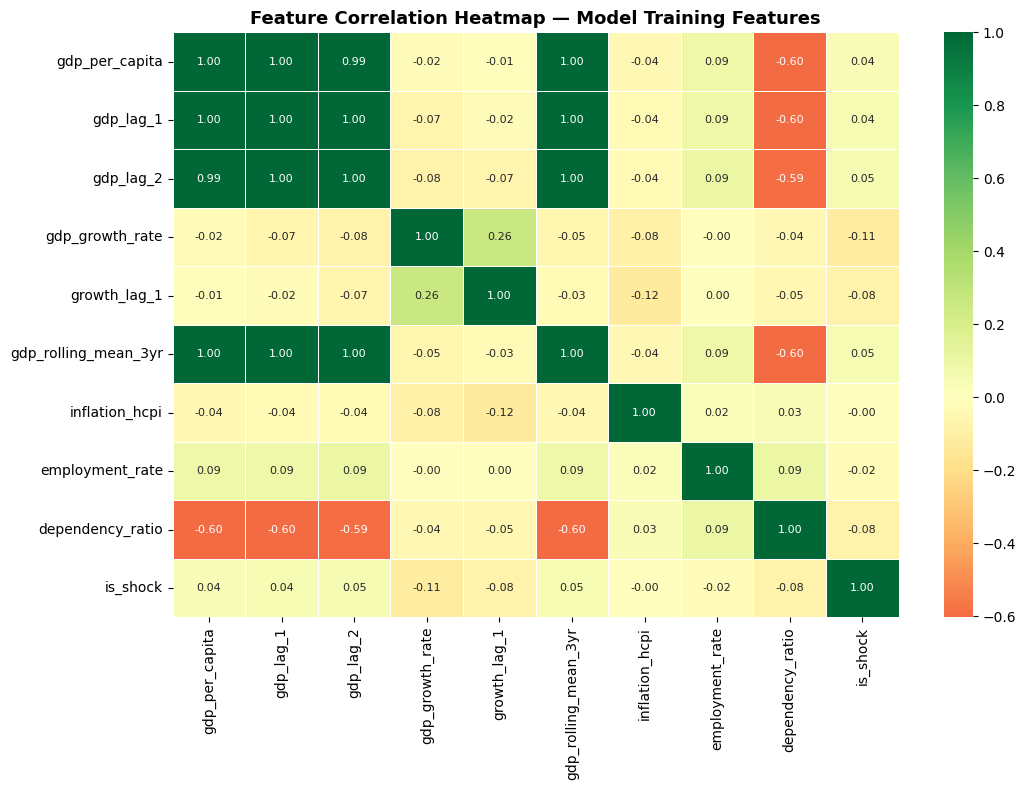

In [18]:
# Correlation heatmap — model training features only
import seaborn as sns

num_cols = [
    "gdp_per_capita", "gdp_lag_1", "gdp_lag_2", "gdp_growth_rate",
    "growth_lag_1", "gdp_rolling_mean_3yr", "inflation_hcpi",
    "employment_rate", "dependency_ratio", "is_shock"
]
num_cols = [c for c in num_cols if c in master.columns]

corr = master[num_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap — Model Training Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(r"..\output\feature_correlation_heatmap.png", dpi=150)
plt.show()

## 13. Global Context Features
World-level signals capturing macroeconomic spillover effects.
These are computed here (data preparation) rather than inside Phase 4 (model-specific logic).

In [19]:
# ── Global Context Features ───────────────────────────────────────────────
# world_gdp_growth          : median GDP growth across all 212 countries per year
# pct_countries_contracting : % of countries with negative growth per year
#
# A country contracting during a global recession behaves differently from one
# contracting in isolation. These features give the model that global awareness.

world_stats = (
    master.groupby("year")["gdp_growth_rate"]
    .agg(
        world_gdp_growth=lambda x: round(x.median(), 4),
        pct_countries_contracting=lambda x: round((x < 0).mean() * 100, 2)
    )
    .reset_index()
)

master = master.merge(world_stats, on="year", how="left")

print("Global context features added.")
print(master[["year", "world_gdp_growth", "pct_countries_contracting"]]
      .drop_duplicates().tail(15).to_string(index=False))

Global context features added.
 year  world_gdp_growth  pct_countries_contracting
 2010            2.9074                    18.4800
 2011            2.7469                    18.0100
 2012            1.5288                    28.4400
 2013            1.6887                    25.0000
 2014            1.7800                    18.8700
 2015            1.6021                    23.1100
 2016            2.0006                    21.7000
 2017            2.2077                    18.4000
 2018            2.0652                    20.2800
 2019            1.7415                    22.6400
 2020           -4.6196                    89.6200
 2021            4.4140                    16.0400
 2022            2.8762                    15.5700
 2023            1.9352                    23.8100
 2024            2.1027                    17.9100


## 14. Save Datasets — Model Training and Dashboard

Two outputs enforce a strict separation between training data and analytical data:

| File | Columns | Used By |
|---|---|---|
| `model_training_dataset.csv` | 14 (zero leakage) | Phases 4, 5, 6 |
| `dashboard_dataset.csv` | All columns | Phase 3, Phase 7/8, Streamlit |

In [20]:
# ── MODEL_FEATURES: the 14 clean, leak-free columns for model training ──────
#
# Excluded and why:
#   recovery_speed_*, recovery_quality_*  — computed using test-period GDP (leakage)
#   gdp_dev_from_*_baseline               — deviation from a baseline using future data
#   pre_shock_baseline_*                  — constant per country, zero time-series signal
#   population, interest_rate             — low predictive power for annual GDP forecasting
#   gdp_lag_3                             — redundant with gdp_rolling_mean_3yr
#   growth_lag_2, growth_lag_3            — redundant with growth_lag_1
#   gdp_rolling_std_*, 5yr rolling        — highly correlated with mean; add noise
#   shock_label                           — string version of is_shock; is_shock encodes same info

MODEL_FEATURES = [
    "country_code", "year",
    "gdp_per_capita",              # current GDP level
    "gdp_lag_1",                   # last year GDP
    "gdp_lag_2",                   # two years ago GDP
    "gdp_growth_rate",             # current year growth rate
    "growth_lag_1",                # last year growth (momentum)
    "gdp_rolling_mean_3yr",        # 3-year rolling trend
    "inflation_hcpi",              # monetary pressure on real output
    "employment_rate",             # labour market health
    "dependency_ratio",            # structural demographic drag
    "is_shock",                    # binary shock period flag
    "world_gdp_growth",            # global macroeconomic context
    "pct_countries_contracting",   # global contagion signal
]

model_df     = master[MODEL_FEATURES].copy()
dashboard_df = master.copy()

OUTPUT_MODEL     = r"..\output\model_training_dataset.csv"
OUTPUT_DASHBOARD = r"..\output\dashboard_dataset.csv"
OUTPUT_RECOVERY  = r"..\output\recovery_summary.csv"

model_df.to_csv(OUTPUT_MODEL, index=False)
dashboard_df.to_csv(OUTPUT_DASHBOARD, index=False)
recovery_summary.to_csv(OUTPUT_RECOVERY, index=False)

print("=" * 60)
print("DATASETS SAVED")
print("=" * 60)
print(f"model_training_dataset.csv : {model_df.shape}   -> Phases 4 / 5 / 6")
print(f"dashboard_dataset.csv      : {dashboard_df.shape}  -> Phase 3 / Streamlit")
print(f"recovery_summary.csv       : {recovery_summary.shape}")
print()
print("Model training features and missing value counts:")
for f in MODEL_FEATURES:
    missing = model_df[f].isnull().sum()
    flag = "  <- has NaNs" if missing > 0 else ""
    print(f"  {f:<35s} missing: {missing}{flag}")
model_df.head()

DATASETS SAVED
model_training_dataset.csv : (7240, 14)   -> Phases 4 / 5 / 6
dashboard_dataset.csv      : (7240, 25)  -> Phase 3 / Streamlit
recovery_summary.csv       : (420, 5)

Model training features and missing value counts:
  country_code                        missing: 0
  year                                missing: 0
  gdp_per_capita                      missing: 0
  gdp_lag_1                           missing: 212  <- has NaNs
  gdp_lag_2                           missing: 424  <- has NaNs
  gdp_growth_rate                     missing: 212  <- has NaNs
  growth_lag_1                        missing: 424  <- has NaNs
  gdp_rolling_mean_3yr                missing: 0
  inflation_hcpi                      missing: 664  <- has NaNs
  employment_rate                     missing: 660  <- has NaNs
  dependency_ratio                    missing: 472  <- has NaNs
  is_shock                            missing: 0
  world_gdp_growth                    missing: 198  <- has NaNs
  pct_countri

,country_code,year,gdp_per_capita,gdp_lag_1,gdp_lag_2,gdp_growth_rate,growth_lag_1,gdp_rolling_mean_3yr,inflation_hcpi,employment_rate,dependency_ratio,is_shock,world_gdp_growth,pct_countries_contracting
0,ABW,1990,33063.0000,NaN,NaN,NaN,NaN,33063.0000,2.8900,NaN,48.3885,0,NaN,0.0000
1,ABW,1991,33993.2070,33063.0000,NaN,2.8134,NaN,33528.1035,2.8900,NaN,50.2383,0,-0.2856,52.2600
2,ABW,1992,34371.1640,33993.2070,33063.0000,1.1119,2.8134,33809.1237,2.8900,NaN,51.0353,0,0.1247,47.7400
3,ABW,1993,34540.3360,34371.1640,33993.2070,0.4922,1.1119,34301.5690,2.8900,NaN,50.4216,0,0.5543,46.2300
4,ABW,1994,35490.7230,34540.3360,34371.1640,2.7515,0.4922,34800.7410,2.8900,NaN,49.7915,0,1.9845,31.0000


---
## Phase 2 Complete

| Feature Group | Features Created |
|---|---|
| Shock labels | `is_shock`, `shock_label` |
| GDP growth | `gdp_growth_rate` |
| Lag features | `gdp_lag_1/2/3`, `growth_lag_1/2/3` |
| Rolling stats | `gdp_rolling_mean/std_3yr/5yr`, `growth_rolling_mean_3yr/5yr` |
| Recovery speed | `recovery_speed_recession_2008`, `recovery_speed_covid_2020` |
| Recovery quality | `recovery_quality_recession_2008`, `recovery_quality_covid_2020` |
| Baseline & deviation | `pre_shock_baseline_2008/2020`, `gdp_dev_from_2008/2020_baseline` |

**Outputs saved:**
- `output/master_enriched.csv` — full enriched dataset for modeling
- `output/recovery_summary.csv` — per-country recovery speed & quality

**Next → Phase 3:** Spatial Analysis of Economic & Demographic Data